# Target Bond Constraints in Retrosynthetic Planning

This tutorial compares an unconstrained SynPlanner search with a search guided by target-bond states passed to `Tree(bonds_state=...)`.

Bond keys are unordered pairs of Chython atom-map numbers:

- State `0` leaves a target bond unconstrained.
- State `1` requires every accepted route to break that bond somewhere, while still allowing preliminary disconnections.
- State `2` freezes a bond: each candidate reaction that breaks it is rejected before entering the tree.

The numbers identify target-derived atoms through immutable provenance. Newly introduced atoms never acquire target identity merely because Chython reuses a number from another fragment. A break means loss of adjacency between the target-derived endpoints; bond-order changes and mapped endpoint element substitutions preserve adjacency.

`Tree` uses `TargetBondConstraints` and `TargetAtomProvenance` from `synplan.chem.target_bonds` internally. This notebook imports the shared `bond_key` and `selected_bonds_svg` helpers from that module while keeping `Tree(bonds_state=...)` as the supported constraint interface.

The constrained example requires `(7, 8)` to break and freezes `(16, 17)`. It compares route and cluster counts with the same search using `bonds_state=None`, then independently audits target-derived adjacency across every constrained winning route.


In [1]:
from pathlib import Path

from synplan.utils.loading import download_preset

# Download the current GPS preset, or reuse an existing local copy.
paths = download_preset("synplanner-gps", save_to="synplan_data")
ranking_policy_network = paths["ranking_policy"]
reaction_rules_path = paths["reaction_rules"]
building_blocks_path = paths["building_blocks"]
 
results_folder = Path("tutorial_results").resolve()
results_folder.mkdir(exist_ok=True)

In [2]:
from synplan.utils.loading import (
    load_building_blocks,
    load_evaluation_function,
    load_policy_function,
    load_reaction_rules,
)

building_blocks = load_building_blocks(
    building_blocks_path,
    standardize=False,
    silent=False,
)
reaction_rules = load_reaction_rules(reaction_rules_path)
policy_function = load_policy_function(weights_path=ranking_policy_network)

In [3]:
from synplan.utils.config import RolloutEvaluationConfig, TreeConfig

tree_config = TreeConfig(
    search_strategy="expansion_first",
    max_iterations=300,
    max_time=120,
    max_depth=9,
    min_mol_size=1,
    init_node_value=0.5,
    ucb_type="uct",
    c_ucb=0.1,
)

eval_config = RolloutEvaluationConfig(
    policy_network=policy_function,
    reaction_rules=reaction_rules,
    building_blocks=building_blocks,
    min_mol_size=tree_config.min_mol_size,
    max_depth=tree_config.max_depth,
)
evaluation_function = load_evaluation_function(eval_config)

In [7]:
from IPython.display import SVG, display
from chython import depict_settings
from synplan.chem.utils import mol_from_smiles

depict_settings(aam=True)

# Review target molecule used for the bond-freeze comparison.
example_smiles = "N#CC1(c2ccc(NC(=O)c3cccnc3NCc3ccncc3)cc2)CCCC1"
target_molecule = mol_from_smiles(
    example_smiles,
    clean2d=True,
    standardize=True,
    clean_stereo=True,
)

target_molecule

## Interpretation

The constraints operate at two levels:

1. **Frozen bonds (state `2`)** are checked for every candidate by comparing target-derived endpoint adjacency directly. A violating candidate is skipped without hiding later valid candidates from the same rule; no CGR composition is needed. 
2. **Required breaks (state `1`)** are tracked independently on every tree branch. Unrelated preliminary disconnections are allowed, but a terminal node is accepted only after all required target adjacencies have disappeared.

Immutable provenance keeps target identity stable across fragmentation and building-block removal. Introduced atoms receive no target identity even when Chython reuses an integer from another fragment. Bond-order changes and mapped endpoint element substitutions remain allowed because the endpoint adjacency survives.

## Select Required and Frozen Bonds

The target depiction shows Chython atom-map numbers. This example assigns the following non-zero states:

```python
{(7, 8): 1, (16, 17): 2}
```

`Tree` normalizes reversed pairs such as `(8, 7)`, rejects conflicting or malformed states, and verifies that every specified pair is a real bond in the standardized target. All unselected bonds behave as state `0`.

These numbers are stable target identities, not route-local labels. Each product inherits provenance only from the precursor being expanded, so a newly introduced atom cannot satisfy or violate a constraint through numeric reuse. Constraints use adjacency only: changing bond order or the element at a mapped endpoint is allowed while the two target-derived endpoints remain connected.


Required breaks: [(7, 8)]
Frozen bonds: [(16, 17)]


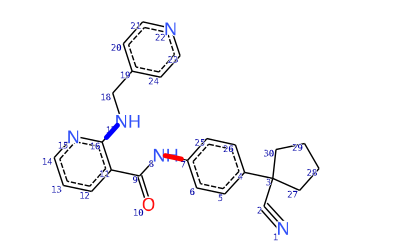

In [13]:
from synplan.chem.target_bonds import bond_key, selected_bonds_svg

bonds_state = {
    (7, 8): 1,
    (16, 17): 2,
}
break_bonds = sorted(bond for bond, state in bonds_state.items() if state == 1)
freeze_bonds = sorted(bond for bond, state in bonds_state.items() if state == 2)

print(f"Required breaks: {break_bonds}")
print(f"Frozen bonds: {freeze_bonds}")
display(SVG(selected_bonds_svg(target_molecule, bonds_state , width="400px", height="250px")))

## Search, Compliance, and Clustering Helpers

Both searches use the same target, policy, rollout evaluation strategy, reaction rules, building blocks, and limits. Only `bonds_state` changes. `tree.run()` executes the search; constraints govern generated tree branches and which terminal nodes can become winning routes, while rollout scoring remains advisory and unchanged.

The compliance helper below does not read `remaining_required_bonds`. It independently walks each winning route, translates each precursor's bonds through stored target-atom provenance, and records which target adjacencies disappear at each step.


RouteCGR composition, SB-CGR reduction, and strategic-bond clustering are provided by the shared `cluster_tree(tree, use_strat=True)` route API, so the notebook does not duplicate that pipeline.

In [14]:
import pandas as pd

from synplan.chem.reaction.routes.clustering import cluster_tree
from synplan.chem.reaction.routes.traversal import iter_route_steps
from synplan.mcts.tree import Tree


def run_search(label, bonds_state=None):
    tree = Tree(
        target=target_molecule,
        config=tree_config,
        reaction_rules=reaction_rules,
        building_blocks=building_blocks,
        expansion_function=policy_function,
        evaluation_function=evaluation_function,
        bonds_state=bonds_state,
    ).run()

    print(
        f"{label}: routes={len(tree.winning_nodes)}, "
        f"unique_route_ids={len(set(tree.winning_nodes))}, "
        f"solved={bool(tree.winning_nodes)}"
    )
    return tree


def precursor_target_edges(precursors):
    edges = set()
    for precursor in precursors:
        local_to_target = precursor.target_atom_provenance.as_dict()
        for atom1, atom2, _bond in precursor.molecule.bonds():
            target1 = local_to_target.get(atom1)
            target2 = local_to_target.get(atom2)
            if target1 is not None and target2 is not None:
                edges.add(bond_key(target1, target2))
    return edges


def winning_route_audit(tree, required_bonds, frozen_bonds):
    required_bonds = set(required_bonds)
    frozen_bonds = set(frozen_bonds)
    rows = []
    for node_id in tree.winning_nodes:
        broken = set()
        for before, after in iter_route_steps(tree, node_id):
            before_edges = precursor_target_edges((before.curr_precursor,))
            after_edges = precursor_target_edges(after.new_precursors)
            broken.update(before_edges - after_edges)
        rows.append(
            {
                "node_id": node_id,
                "broken_target_bonds": sorted(broken),
                "all_required_broken": required_bonds <= broken,
                "no_frozen_broken": frozen_bonds.isdisjoint(broken),
            }
        )
    return pd.DataFrame(rows)


def cluster_summary_rows(label, clusters, required_bonds, frozen_bonds):
    required_bonds = set(required_bonds)
    frozen_bonds = set(frozen_bonds)
    rows = []
    for cluster_id, cluster in clusters.items():
        strat_bonds = set(cluster.get("strat_bonds") or [])
        rows.append(
            {
                "scenario": label,
                "cluster_id": cluster_id,
                "group_size": cluster.get("group_size", len(cluster.get("route_ids", []))),
                "strat_bonds": sorted(strat_bonds),
                "required_breaks_present": sorted(strat_bonds & required_bonds),
                "frozen_breaks_present": sorted(strat_bonds & frozen_bonds),
            }
        )
    return rows


## Run Baseline and Constrained Searches

In [ ]:
baseline_tree = run_search("Baseline (bonds_state=None)", bonds_state=None)
constrained_tree = run_search("Required (7, 8); frozen (16, 17)", bonds_state=bonds_state)


constrained_route_audit = winning_route_audit(
    constrained_tree, break_bonds, freeze_bonds
)
display(constrained_route_audit)


  0%|          | 0/300 [00:00<?, ?it/s]

Baseline (bonds_state=None): routes=905, unique_route_ids=905, solved=True


  0%|          | 0/300 [00:00<?, ?it/s]

Required (7, 8); frozen (16, 17): routes=400, unique_route_ids=400, solved=True


,node_id,broken_target_bonds,all_required_broken,no_frozen_broken
0,355,"[(7, 8), (17, 18)]",True,True
1,362,"[(7, 8), (17, 18)]",True,True
2,391,"[(7, 8), (17, 18)]",True,True
3,398,"[(7, 8), (17, 18)]",True,True
4,575,"[(7, 8), (9, 10)]",True,True
...,...,...,...,...
395,3796,"[(7, 8), (8, 9), (9, 10)]",True,True
396,3797,"[(7, 8), (8, 9), (9, 10)]",True,True
397,3803,"[(7, 8), (8, 9), (9, 10)]",True,True
398,3804,"[(7, 8), (8, 9), (9, 10)]",True,True


## Compare Route And Cluster Counts

In [16]:
baseline_route_cgrs, baseline_sb_cgrs, baseline_clusters = cluster_tree(baseline_tree)
constrained_route_cgrs, constrained_sb_cgrs, constrained_clusters = cluster_tree(
    constrained_tree
)

summary = pd.DataFrame(
    [
        {
            "scenario": "Baseline",
            "routes_found": len(baseline_tree.winning_nodes),
            "route_cgrs_composed": len(baseline_route_cgrs),
            "clusters": len(baseline_clusters),
        },
        {
            "scenario": "Required (7, 8); frozen (16, 17)",
            "routes_found": len(constrained_tree.winning_nodes),
            "route_cgrs_composed": len(constrained_route_cgrs),
            "clusters": len(constrained_clusters),
        },
    ]
)
summary

,scenario,routes_found,route_cgrs_composed,clusters
0,Baseline,905,905,32
1,"Required (7, 8); frozen (16, 17)",400,400,13


## Inspect Cluster Strategy Bonds

The route audit above verifies every accepted route directly from target-derived adjacency changes. The tables below provide a complementary clustering view through each cluster's `strat_bonds`: constrained clusters should include required break `(7, 8)`, while frozen bond `(16, 17)` must not appear as a broken strategic bond.


(<Figure size 500x500 with 1 Axes>,
 <Axes: title={'center': 'SB-CGR overlap: 3 shared'}>)

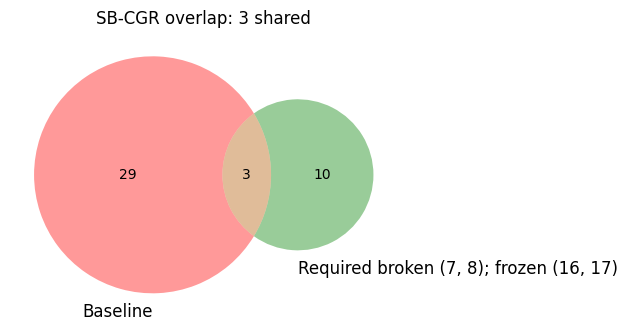

In [41]:
from synplan.chem.reaction.routes.notebook_plots import plot_sb_cgr_cluster_venn
from synplan.chem.reaction.routes.analysis import compare_sb_cgr_clusters

cluster_overlap = compare_sb_cgr_clusters(baseline_clusters, constrained_clusters)

plot_sb_cgr_cluster_venn(baseline_clusters, constrained_clusters, labels=["Baseline", "Required broken (7, 8); frozen (16, 17)"])

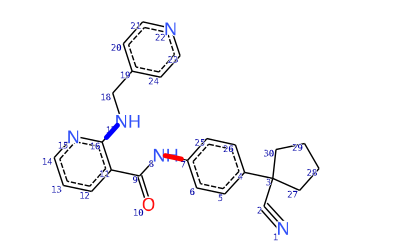

In [39]:
display(SVG(selected_bonds_svg(target_molecule, bonds_state , width="400px", height="250px")))

This shared SB-CGR occurs in both searches, showing that the constraints retain route families whose strategic disconnections already break `(7, 8)` without breaking `(16, 17)`.

In [ ]:
common_sb_cgr = baseline_clusters[cluster_overlap['overlap_cluster_ids'][0][0]]['sb_cgr']
common_sb_cgr.clean2d()
common_sb_cgr

This baseline-only SB-CGR occurs only in the unconstrained result, representing a route family that is either incompatible with the selected bond conditions or not revisited within the constrained search budget.

In [37]:
baseline_only_cluster = baseline_clusters[cluster_overlap['unique_cluster_ids_1'][0]]['sb_cgr']
baseline_only_cluster.clean2d()
baseline_only_cluster

This constrained-only SB-CGR occurs only in the constrained result, showing how filtering noncompliant branches redirects the finite search toward a different compliant route family.

In [38]:
constrained_only_cluster = constrained_clusters[cluster_overlap['unique_cluster_ids_2'][0]]['sb_cgr']
constrained_only_cluster.clean2d()
constrained_only_cluster

In [45]:
cluster_details_baseline = pd.DataFrame(
    cluster_summary_rows(
        "Baseline", baseline_clusters, break_bonds, freeze_bonds
    )
)
cluster_details_constrained = pd.DataFrame(
    cluster_summary_rows(
        "Required (7, 8); frozen (16, 17)",
        constrained_clusters,
        break_bonds,
        freeze_bonds,
    )
)

SHOW_MAX_ROWS = 5

with pd.option_context("display.max_rows", None, "display.max_colwidth", None):
    display(cluster_details_baseline.sort_values(["scenario", "cluster_id"])[:SHOW_MAX_ROWS])
    display(cluster_details_constrained.sort_values(["scenario", "cluster_id"])[:SHOW_MAX_ROWS])

,scenario,cluster_id,group_size,strat_bonds,required_breaks_present,frozen_breaks_present
0,Baseline,2.1,52,"[(7, 8), (9, 10)]","[(7, 8)]",[]
1,Baseline,2.2,82,"[(7, 8), (16, 17)]","[(7, 8)]","[(16, 17)]"
2,Baseline,2.3,28,"[(7, 8), (17, 18)]","[(7, 8)]",[]
3,Baseline,2.4,23,"[(8, 9), (9, 10)]",[],[]
4,Baseline,2.5,295,"[(8, 9), (16, 17)]",[],"[(16, 17)]"


,scenario,cluster_id,group_size,strat_bonds,required_breaks_present,frozen_breaks_present
0,"Required (7, 8); frozen (16, 17)",2.1,156,"[(7, 8), (9, 10)]","[(7, 8)]",[]
1,"Required (7, 8); frozen (16, 17)",2.2,28,"[(7, 8), (17, 18)]","[(7, 8)]",[]
2,"Required (7, 8); frozen (16, 17)",3.1,1,"[(2, 3), (7, 8), (9, 10)]","[(7, 8)]",[]
3,"Required (7, 8); frozen (16, 17)",3.2,2,"[(3, 4), (7, 8), (9, 10)]","[(7, 8)]",[]
4,"Required (7, 8); frozen (16, 17)",3.3,40,"[(7, 8), (8, 9), (9, 10)]","[(7, 8)]",[]
